1本目のスパイラル（真の軌道）: [(0.0, 0.0), (0.09950041652780259, 0.009983341664682815), (0.19601331556824833, 0.03973386615901225), (0.2866009467376818, 0.0886560619984019), (0.3684243976011541, 0.15576733692346023), (0.4387912809451864, 0.2397127693021015), (0.495201368945807, 0.33878548403702136), (0.5353895310991419, 0.45095238106638386), (0.5573653674777324, 0.5738848727196183), (0.559448971443598, 0.7049942186647351), (0.5403023058681398, 0.8414709848078965), (0.4989557335681351, 0.9803280960675791), (0.43482930537200815, 1.1184469031606719), (0.34774847721196356, 1.2526256410423509), (0.23795400006033715, 1.3796296219838444), (0.10610580250155435, 1.4962424799060816), (-0.046719235682062106, 1.5993177648664083), (-0.21903564030239228, 1.6858301777691966), (-0.40896377044755683, 1.7529257355807513), (-0.6142501770406569, 1.7979701666060877), (-0.8322936730942848, 1.8185948536513634), (-1.060176819659701, 1.8127396699626348), (-1.294702457961761, 1.7786920884030983), (-1.5324348489435964, 1.715

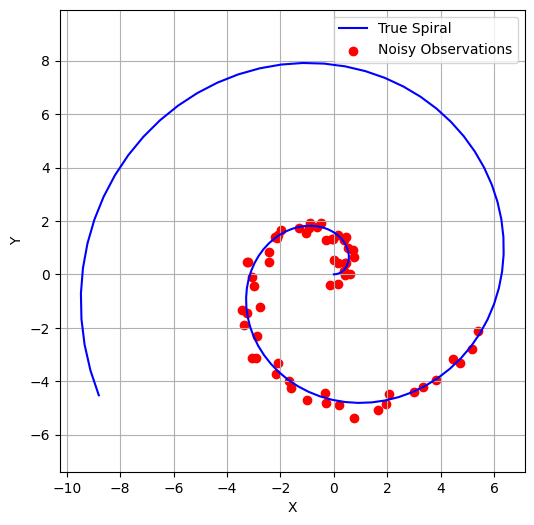

In [1]:


import math #数学関数(sin,cosなど)
import random #乱数
import torch

#乱数固定→ノイズ付きデータを固定できる。もし毎回違う形にしたいなら下の2行を外す
random.seed(0)
torch.manual_seed(0)

# ## スパイラルの構築
# - スパイラルの式（極座標）： r=a+bΘ
# - rは半径,Θは角度

#ライブラリ無しで「0~6π」をn個に分けたい
def linspace(start,stop,num):
    if num==1:
        return [start]
    step=(stop-start)/(num-1)
    return[start+i*step for i in range(num)]


linspace(0,6,5)

#スパイラルの座標を計算する
def generate_spiral_points (ntotal,a,b):
    points=[] #座標を入れる箱
    for i in range(ntotal):
        theta = i * 0.1  # θを少しずつ大きくする（0.1ラジアン刻み）
        r=a+b*theta
        x=r*math.cos(theta)
        y=r*math.sin(theta)
        points.append((x,y)) # 「~.append」でリストの末尾に要素を追加。ここではpointsリストの末尾に要素を加えていく    
    return(points)



# ノイズを加える関数を作る
# 正規分布ノイズをライブラリ無しで作るにはBox-Muller法を使う
def gaussian_noise(std):
    u1=random.random() # ランダム関数発動。「random.random()」で、0.0以上1.0未満の浮動小数点数の乱数を生成
    u2=random.random()
    z=math.sqrt(-2*math.log(u1))*math.cos(2*math.pi*u2)
    return z*std


# ランダムな一部をサンプルしてノイズを加える
def sample_with_noise(points,nsample,noise_std):
    if nsample > len(points):
        raise ValueError(f"nsample（{nsample}）はデータ数（{len(points)}）以下にしてください。")
    #start_index=random.randint(0,len(points)-nsample) # random.randint(a,b)で、a<=n<=bの範囲のランダムな整数を返す
    start_index = 0  #ノイズデータの始点を(0,0)からに固定
    sampled=[] # ノイズを加えたデータを入れる箱
    for i in range(start_index,start_index+nsample):
        x,y=points[i] #pointsリストのi番目の要素の座標をx,yにそれぞれ代入
        x +=gaussian_noise(noise_std) #関数gaussian_noise発動
        y +=gaussian_noise(noise_std)
        sampled.append((x,y))
    return sampled


# 全部まとめて関数化する
def generate_spiral_data(nspiral=1,ntotal=100,nsample=60,a=0,b=1,noise_std=0.25): 
    # 「nspiral」はスパイラルの本数,「ntotal」は正解スパイラルのデータ点の数,「nsample」はノイズ付きデータのデータ点の数
    #「a,b」はスパイラル生成で使う変数,「noise_std」はノイズ付きデータを作るときに使うばらつきの強度。値が大きくなるとばらつきも大きい
    
    
    if nsample > ntotal:
        raise ValueError(f"nsample({nsample}) は ntotal({ntotal}) 以下にしてください。")

    all_true=[] # 教師データ
    all_obs=[] # 観測データ（Observation）
    for _ in range(nspiral): # 「for _ in range(ooo)」は「for i in range(ooo)」のように書いてもOKです。 変数名が「_」になっているだけです。
        is_ccw = random.random()>0.5  #50％の確率で時計回りor反時計回り。is_ccw（is counter-clockwise）は、ランダムに True（反時計）か False（時計）を選びます。
        sign = 1 if is_ccw else -1 # 条件式が真のときに評価される式 if 条件式 else 条件式が偽のときに評価される式。
        spiral=generate_spiral_points(ntotal,a,b*sign) #関数generate_spiral_points発動
        obs=sample_with_noise(spiral,nsample,noise_std) #関数sample_with_noise発動
        all_true.append(spiral)
        all_obs.append(obs)
    return all_true,all_obs


true_paths, noisy_samples = generate_spiral_data()
print("1本目のスパイラル（真の軌道）:", true_paths[0])
print("1本目の観測データ（ノイズあり）:", noisy_samples[0])


import matplotlib.pyplot as plt


# 描画する前にデータを整理
def data_cleaning(true_paths,noisy_samples):
    for i in range(len(true_paths)):
        true=true_paths[i]
        noisy=noisy_samples[i]

        true_x=[p[0] for p in true] #リスト内包表記。trueの中のすべての点pから、x座標（p[0]）だけを取り出してリストにする
        true_y=[p[1] for p in true] #「for p in true」はtrueというリストの中から要素をpに取り出す

        noisy_x=[p[0] for p in noisy]
        noisy_y=[p[1] for p in noisy]
    return true_x,true_y,noisy_x,noisy_y
        
true_x,true_y,noisy_x,noisy_y=data_cleaning(true_paths, noisy_samples) #data_cleaning関数発動して各変数に代入
plt.figure(figsize=(6,6)) #「plt.figure」で新しい図（キャンバス）を作る。figsize=(o,o)でサイズ指定(単位はインチ)
plt.plot(true_x,true_y,label='True Spiral',color='blue')
plt.scatter(noisy_x,noisy_y,label='Noisy Observations',color='red') #「plt.scatter(x, y, label="○○")」で散布図を描く関数

plt.xlabel('X')
plt.ylabel('Y')
plt.legend() #上で指定した、label="○○"で付けた名前を表示してくれる
plt.axis('equal') #スケールを同じにする
plt.grid(True) #グリッド線を引くか
plt.show() #これを言わんと出力されん













1 回目
Step 0, Loss 7.2549
Step 100, Loss 0.2515
Step 200, Loss 0.0660
Step 300, Loss 0.0602
Step 400, Loss 0.0571
Step 500, Loss 0.0806
Step 600, Loss 0.0534
Step 700, Loss 0.0526
Step 800, Loss 0.0521
Step 900, Loss 0.0538
Step 999, Loss 0.0510
2 回目
Step 0, Loss 6.5011
Step 100, Loss 0.2368
Step 200, Loss 0.0603
Step 300, Loss 0.0569
Step 400, Loss 0.0536
Step 500, Loss 0.0807
Step 600, Loss 0.0654
Step 700, Loss 0.0517
Step 800, Loss 0.0508
Step 900, Loss 0.0505
Step 999, Loss 0.0502
[[np.float64(-0.16342117), np.float64(-0.40995103)], [np.float64(-0.1085380175), np.float64(-0.38538082500000004)], [np.float64(-0.053557859), np.float64(-0.35553854500000004)], [np.float64(0.0010939907000000002), np.float64(-0.32041708)], [np.float64(0.0549751535), np.float64(-0.2800669)], [np.float64(0.107631405), np.float64(-0.23460066499999999)], [np.float64(0.15860293), np.float64(-0.184192305)], [np.float64(0.20743089999999997), np.float64(-0.129075765)], [np.float64(0.25366432), np.float64(-0.06954

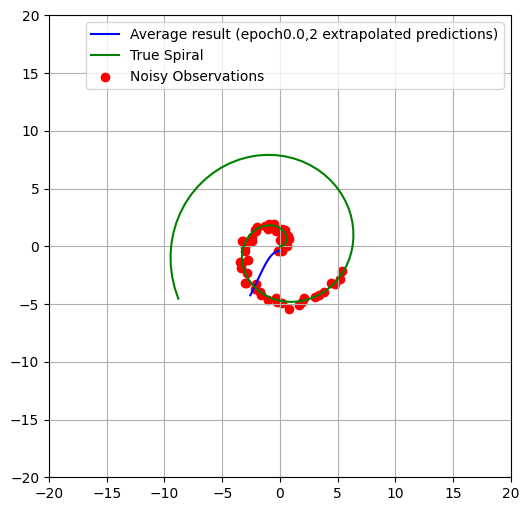

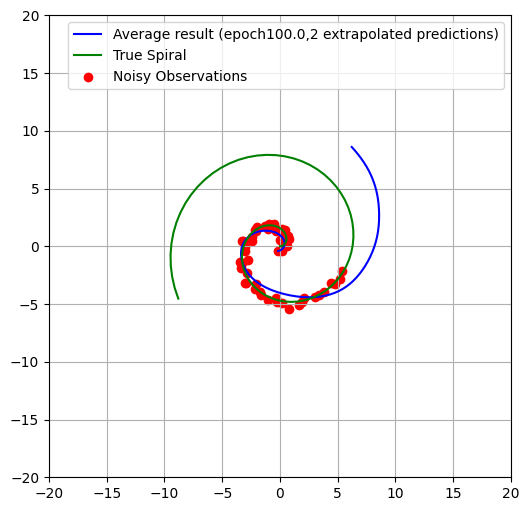

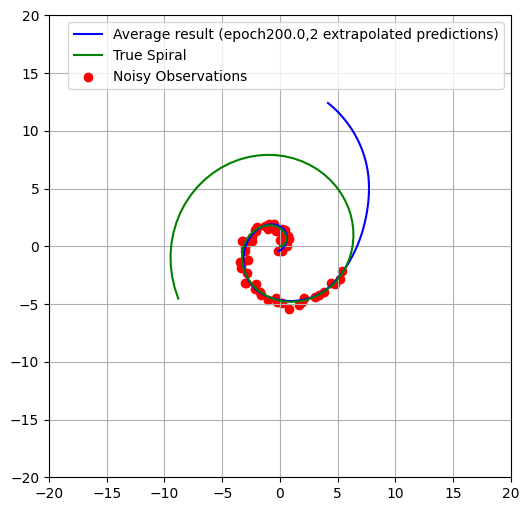

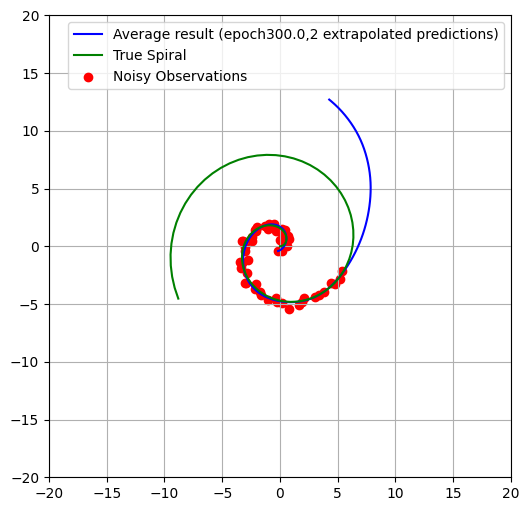

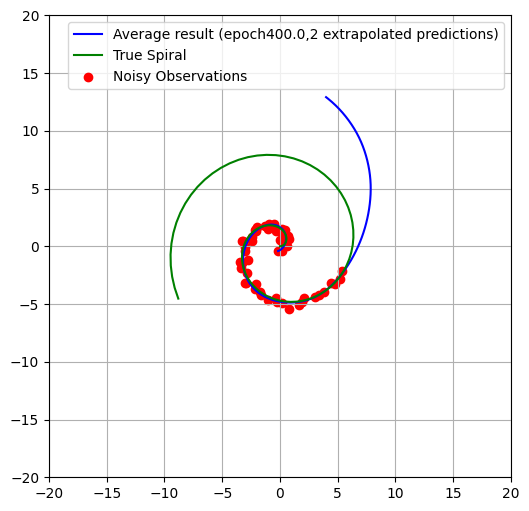

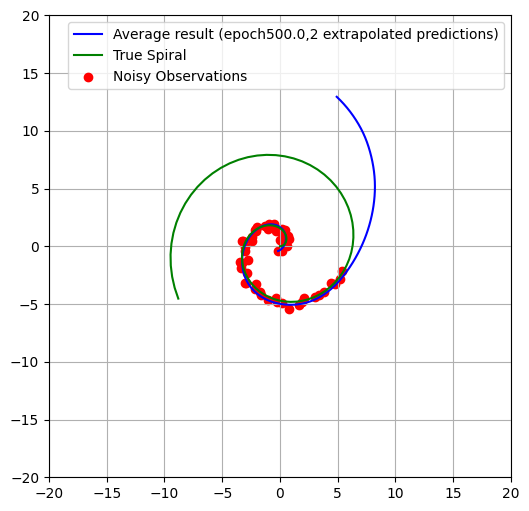

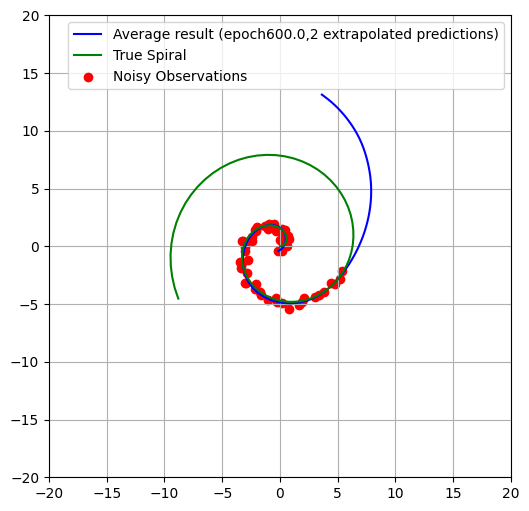

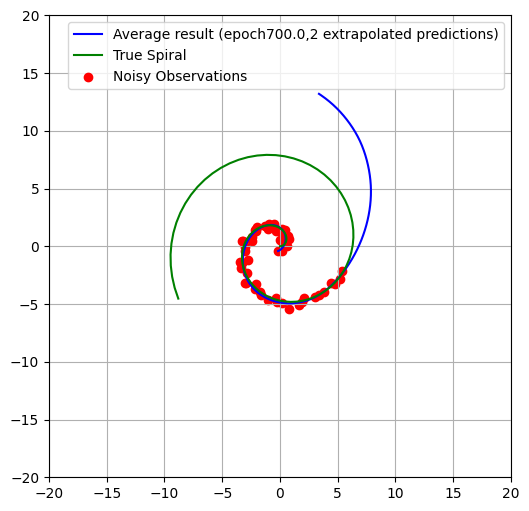

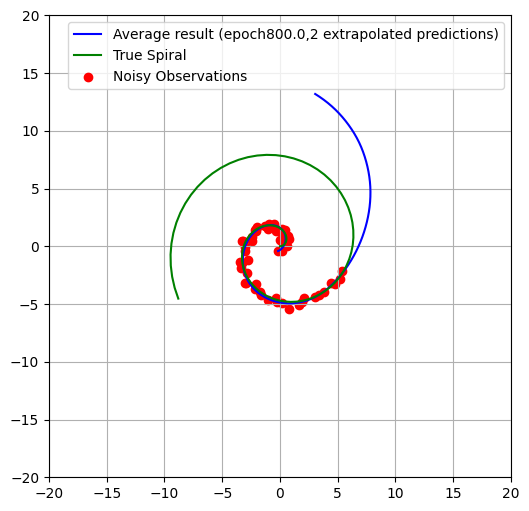

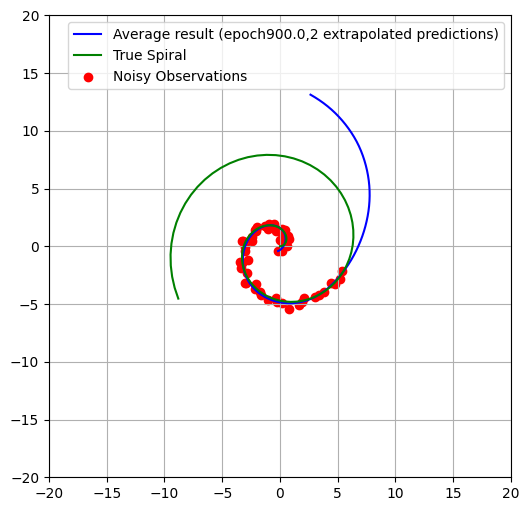

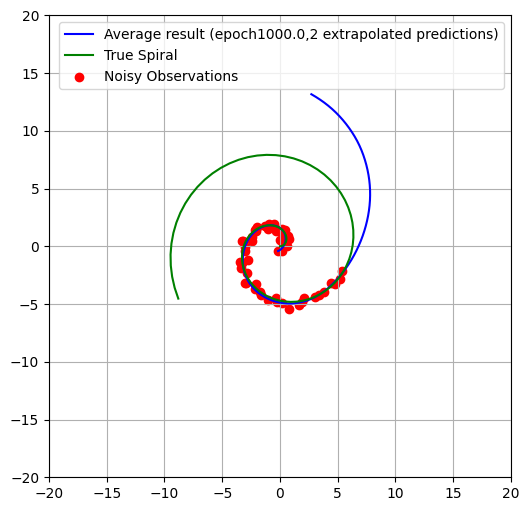

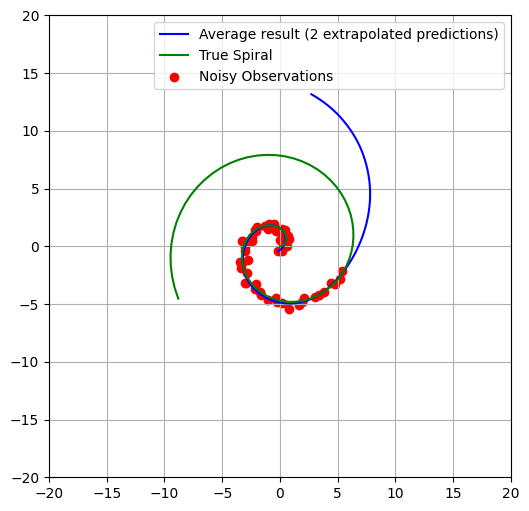

画像を保存しました: output_images\plot_20251210_155418.png
2.1506046573321025 分
1 回目
Step 0, Loss 5.0580
Step 100, Loss 3.0138
Step 200, Loss 0.2168
Step 300, Loss 0.0781
Step 400, Loss 0.0692
Step 500, Loss 0.0631
Step 600, Loss 0.0591
Step 700, Loss 0.0567
Step 800, Loss 0.0553
Step 900, Loss 0.0545
Step 999, Loss 0.0538
2 回目
Step 0, Loss 7.5194
Step 100, Loss 7.8960
Step 200, Loss 4.9159
Step 300, Loss 4.2809
Step 400, Loss 4.0499
Step 500, Loss 2.6978
Step 600, Loss 0.2217
Step 700, Loss 0.0736
Step 800, Loss 0.0666
Step 900, Loss 0.0636
Step 999, Loss 0.0612
[[np.float64(-0.16342117), np.float64(-0.40995103)], [np.float64(-0.114041225), np.float64(-0.391207635)], [np.float64(-0.06440591500000001), np.float64(-0.367690745)], [np.float64(-0.0148689515), np.float64(-0.33933601)], [np.float64(0.034205313), np.float64(-0.30611971)], [np.float64(0.0824465), np.float64(-0.26805794)], [np.float64(0.12948326), np.float64(-0.225209895)], [np.float64(0.17494841), np.float64(-0.177673255)], [np.float6

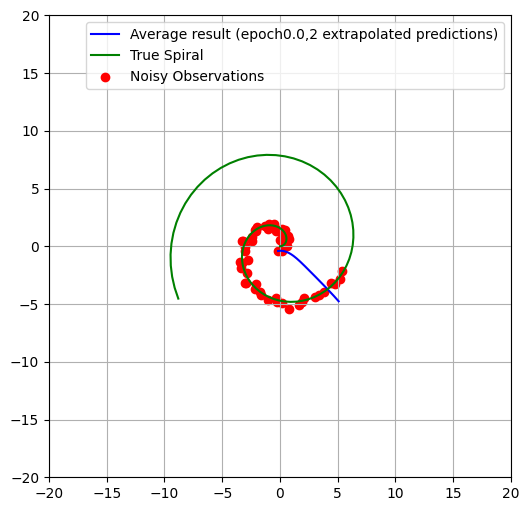

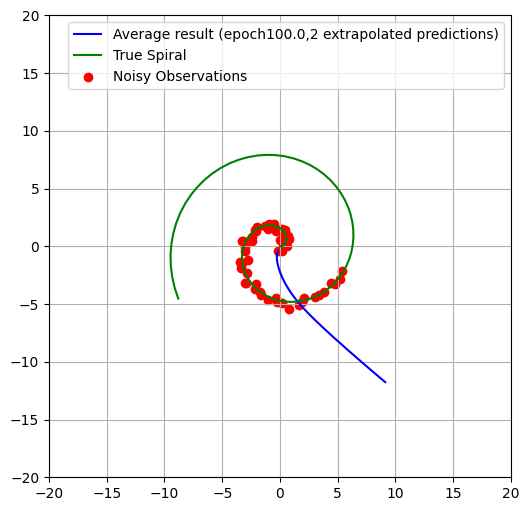

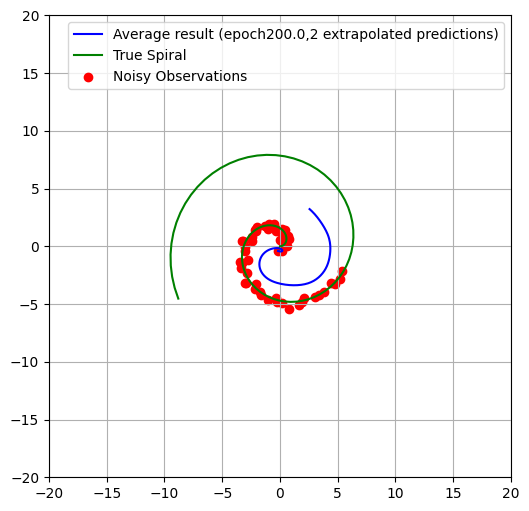

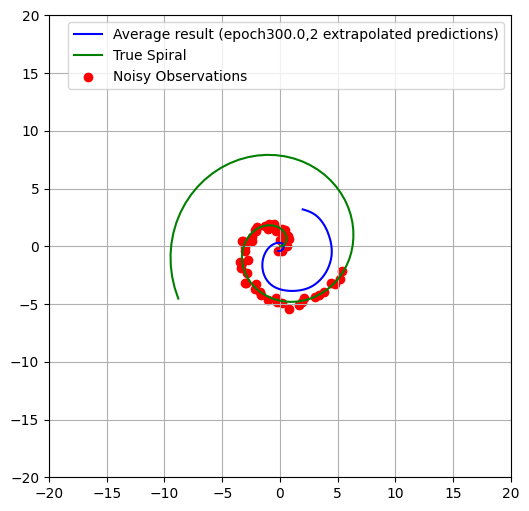

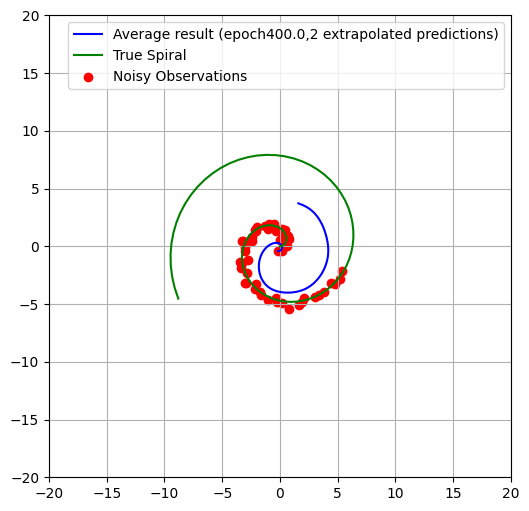

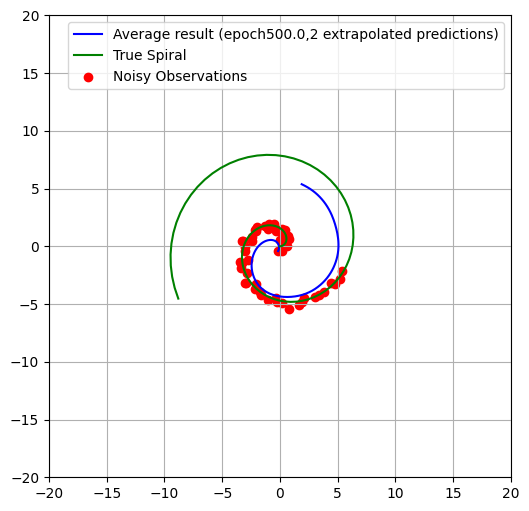

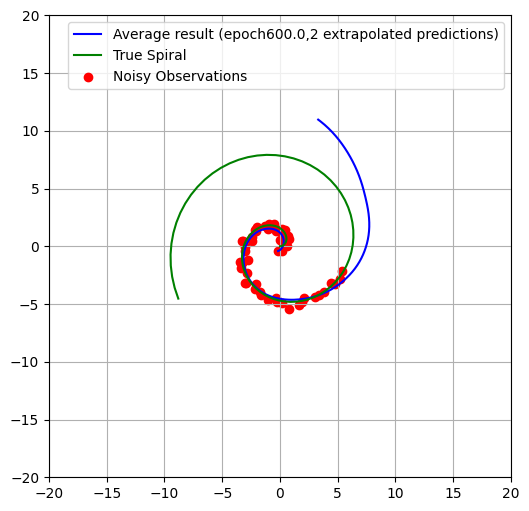

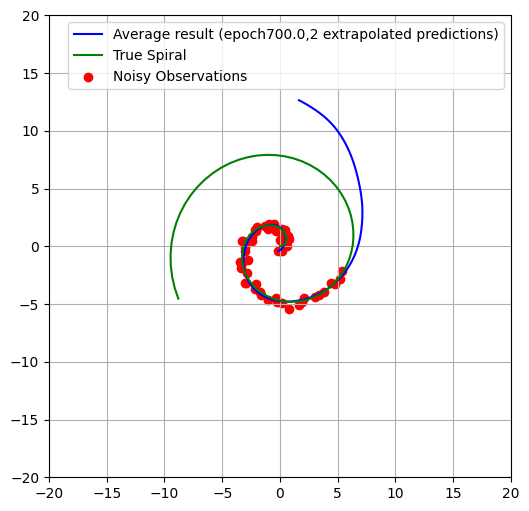

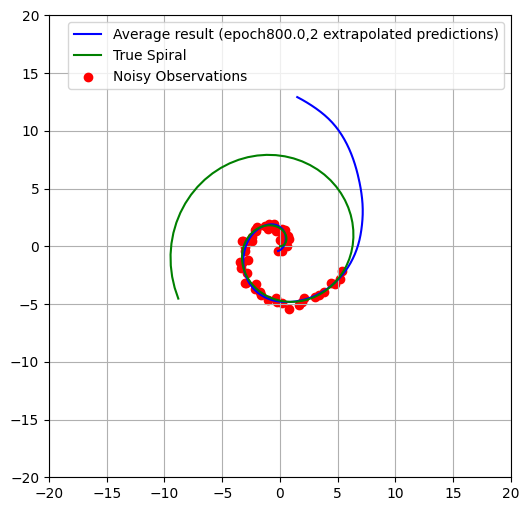

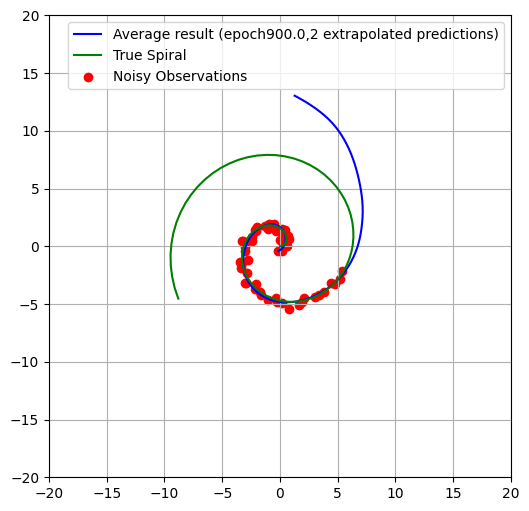

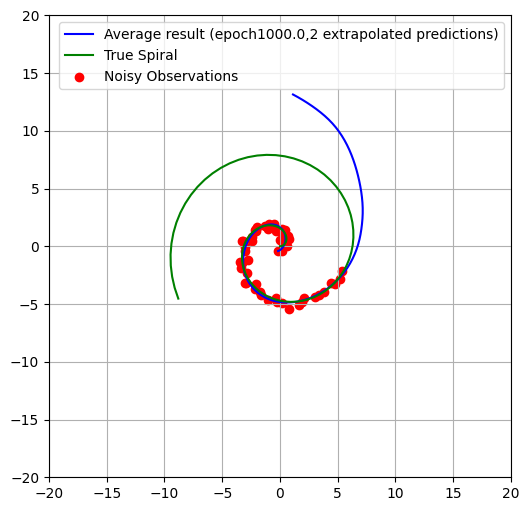

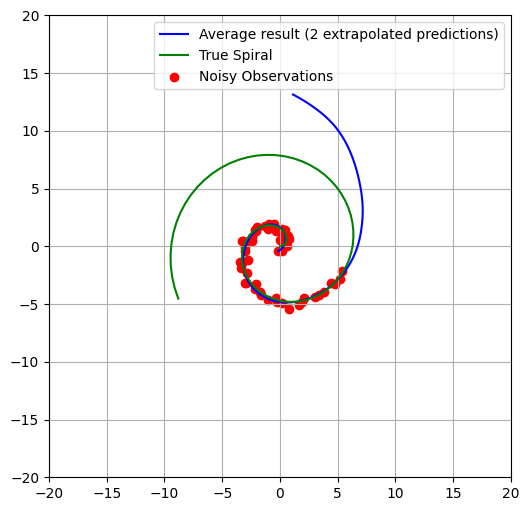

画像を保存しました: output_images\plot_20251210_155615.png
1.9521616021792094 分
1 回目
Step 0, Loss 6.1744
Step 100, Loss 0.2137
Step 200, Loss 0.0628
Step 300, Loss 0.0577
Step 400, Loss 0.0639
Step 500, Loss 0.0521
Step 600, Loss 0.0516
Step 700, Loss 0.0750
Step 800, Loss 0.0504
Step 900, Loss 0.0502
Step 999, Loss 0.0504
2 回目
Step 0, Loss 5.2330
Step 100, Loss 0.1062
Step 200, Loss 0.0706
Step 300, Loss 0.0621
Step 400, Loss 0.0617
Step 500, Loss 0.0554
Step 600, Loss 0.0540
Step 700, Loss 0.0556
Step 800, Loss 0.0523
Step 900, Loss 0.0517
Step 999, Loss 0.0580
[[np.float64(-0.16342117), np.float64(-0.40995103)], [np.float64(-0.106111592), np.float64(-0.38454668000000003)], [np.float64(-0.049049102), np.float64(-0.35420866500000003)], [np.float64(0.007321432915), np.float64(-0.31897295000000003)], [np.float64(0.06254516), np.float64(-0.27892497)], [np.float64(0.1161633), np.float64(-0.23419693)], [np.float64(0.16772028), np.float64(-0.184968525)], [np.float64(0.21677058999999999), np.float64(

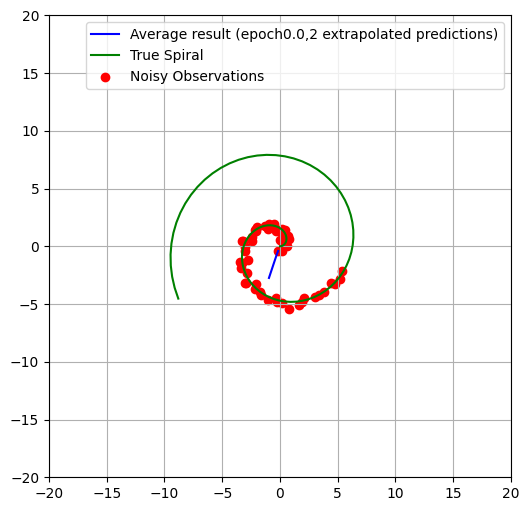

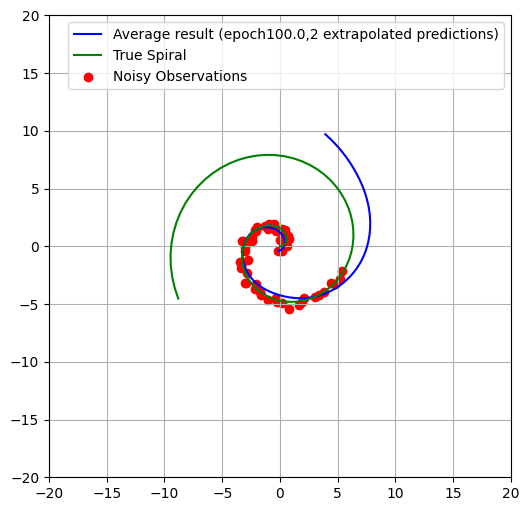

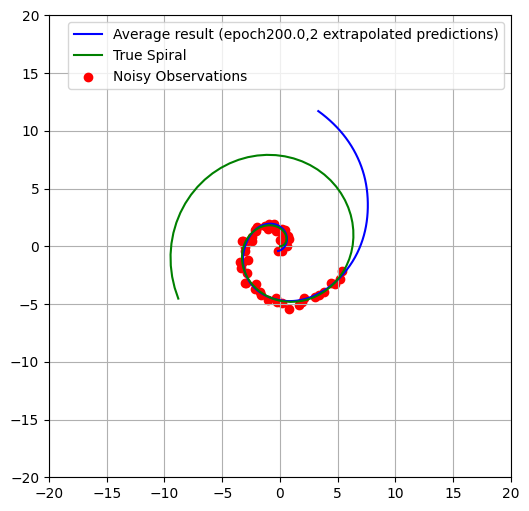

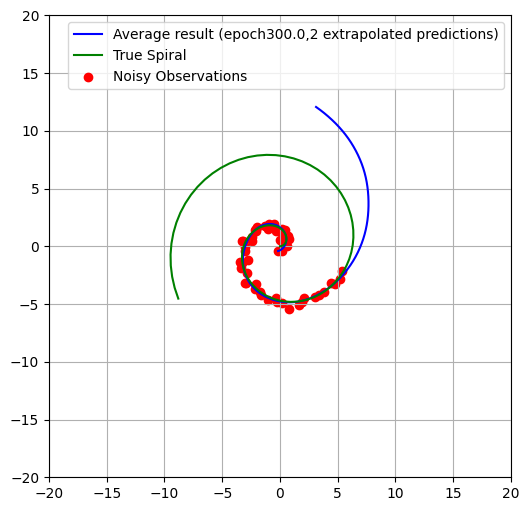

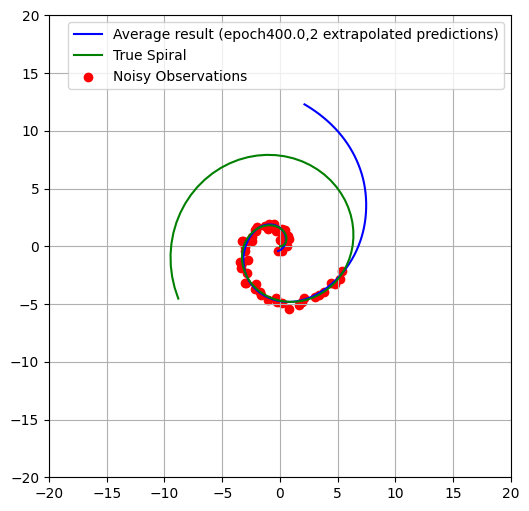

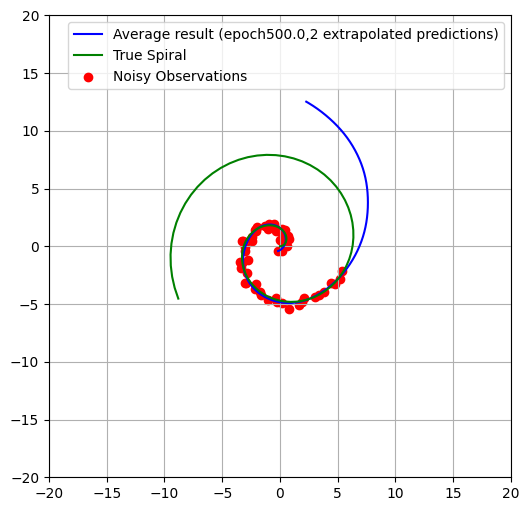

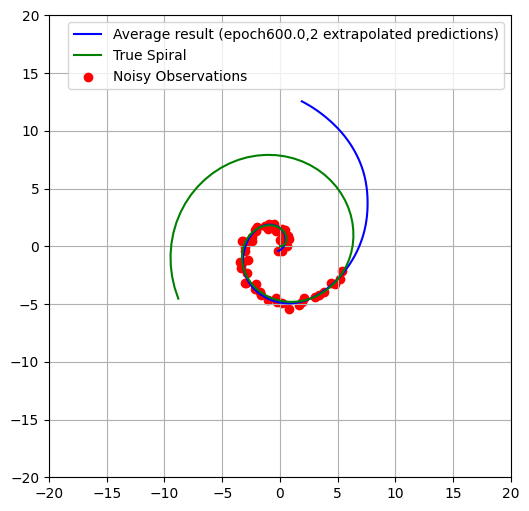

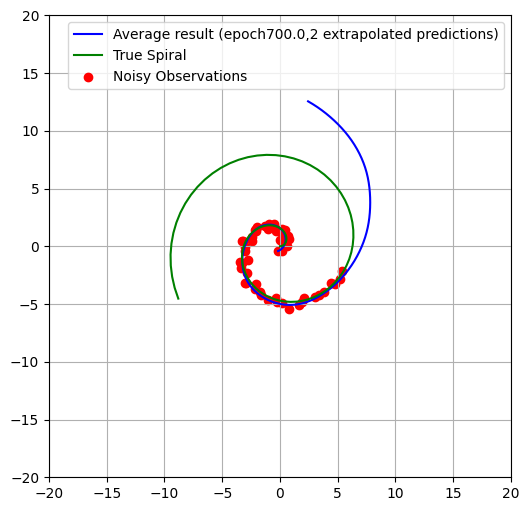

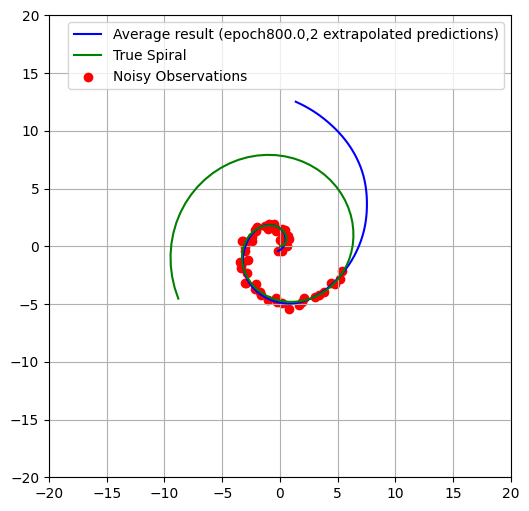

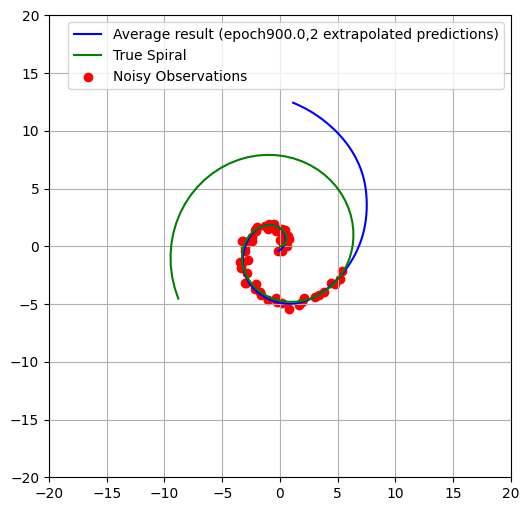

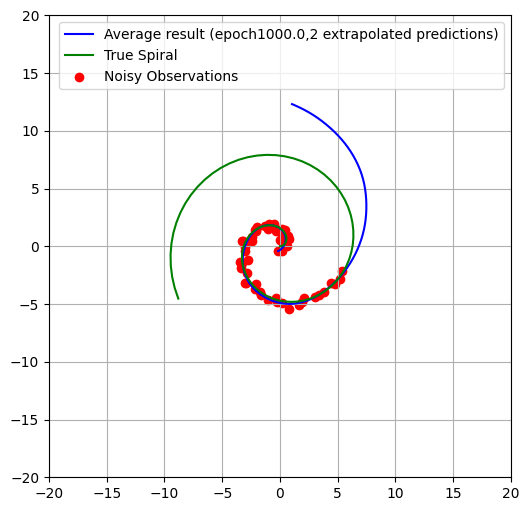

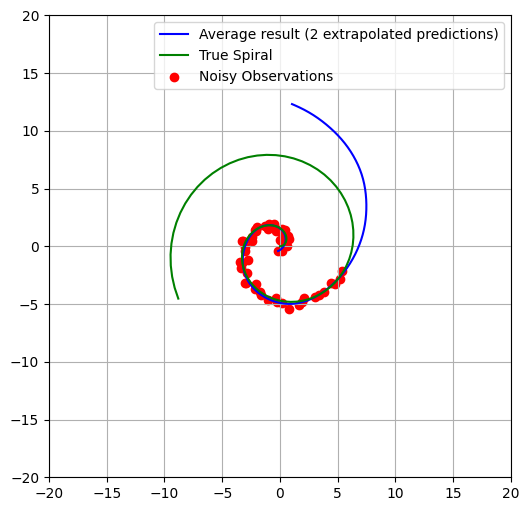

画像を保存しました: output_images\plot_20251210_155824.png
2.1503808299700418 分


In [3]:

import pandas as pd
import time
import numpy as np



for g in range (3):
    start = time.time()  # 現在時刻（処理開始前）を取得
    all_result=[]# すべての外挿結果を格納するリスト
    step_result=[]# 100ステップごとの外挿結果を入れるリスト
    n=2 #外挿を何セットやりたいか
    m=1000 # 学習回数（エポック数）
    
    for j in range(n):
        # 観測データの整形
        # 時間の配列。stepsは観測点数。つまりノイズデータの数

        #回帰実験用↓
        # t=torch.linspace(0,6,steps=60) #torch.linspace(開始,終了,oo分割)でtensorの配列を作る

        # 外挿用↓
        # t_train = torch.linspace(0, 6, steps=120)←この行は無視
        t_train =torch.linspace(0,6,steps=60)  # 60ステップに修正

        #回帰用
        #データ整形（バッチ×時刻×次元数）
        # x=torch.tensor(noisy_samples[0],dtype=torch.float32) # 1つ目のスパイラル観測点
        # x=x.unsqueeze(0) #

        # 外挿用
        
        x_train = torch.tensor(noisy_samples[0], dtype=torch.float32).unsqueeze(0)




        import torch.nn as nn

        # dy/dt = f(y, t) の f をNNで定義
        class ODEFunc(nn.Module):
            def __init__(self):
                super().__init__()
                self.net = nn.Sequential(
                    nn.Linear(2, 50),
                    #nn.ReLU(),
                    nn.Tanh(),
                    # nn.LeakyReLU(negative_slope=0.01),
                    nn.Linear(50, 2),
                )

            def forward(self, t, y):
                return self.net(y)



        from torchdiffeq import odeint

        # ODEFuncをインスタンス化
        func = ODEFunc()


        # 初期状態(回帰用)（時刻t=0での位置）を決める
        # y0 = x[:, 0, :]  # shape: (1, 2)

        # 初期状態(外挿用)（時刻t=0での位置）を決める
        y0 = x_train[:, 0] # [:,x]スライス構文。「:」はすべての要素を取るの意味。xは何列目かを表す。つまりこの場合、x_trainのリストの内、0列目をすべて取るの意味
        # 最初の時刻の観測点（形状は [1, 2]）


        # ODEを解いて系列を得る（tに沿って解く）回帰用↓
        # pred_y = odeint(func, y0, t)  # shape: (30, 1, 2)
        # pred_y = pred_y.permute(1, 0, 2)  # shape: (1, 30, 2)




        optimizer = torch.optim.Adam(func.parameters(), lr=0.01)# 学習率lr 
        loss_fn = nn.MSELoss()# MSELoss:平均二乗誤差

        """
        #回帰用
        for itr in range(1000):
            optimizer.zero_grad()
            pred_y = odeint(func, y0, t).permute(1, 0, 2)
            loss = loss_fn(pred_y, x)
            loss.backward()
            optimizer.step()


            if itr % 100 == 0:
                print(f"Step {itr}, Loss {loss.item():.4f}")
            
        pred_x = pred_y[0].detach().numpy()    
        """

        print(j+1,"回目")
        # 外挿用
        for itr in range(m):
            optimizer.zero_grad()
            pred_y = odeint(func, y0, t_train) #[60, 1, 2]
            pred_y = pred_y.permute(1, 0, 2) #[1, 60, 2]
            loss = loss_fn(pred_y, x_train)
            loss.backward()
            optimizer.step()

            
            if itr % 100 == 0 or itr==999:
                
                print(f"Step {itr}, Loss {loss.item():.4f}")

                #100ステップごとに外挿を行う
                t_extrapolate = torch.linspace(0, 10, steps=200)  # 外挿の時間範囲
                pred_y_extrapolated = odeint(func, y0, t_extrapolate).squeeze(1).detach().numpy() 
                df = pd.DataFrame(pred_y_extrapolated,columns=["x","y"])
                df["試行回数"]=f"(エポック{itr},試行回数{j+1})"# 何回目の繰り返しかを記録
                step_result.append(df)
        
        # n回の外挿のデータセットを1つのDataFrameにまとめる（外挿の平均実験用に追加）
        step_result_df = pd.concat(step_result, ignore_index=True)# 新しいindexを0から順に振り直す（重複なし）

        # CSVファイルに保存（外挿の平均実験用に追加）
        step_result_df.to_csv("pred_y_extrapolated_step.csv", index=False, encoding="utf-8")# 「index=False にするのは、余分なインデックス列を省くため」





        t_extrapolate = torch.linspace(0, 10, steps=200)  # 外挿の時間範囲
        pred_y_extrapolated = odeint(func, y0, t_extrapolate).squeeze(1).detach().numpy() # 外挿予測した結果を格納

        # print(j+1,"回目外挿予測結果データ:",pred_y_extrapolated)
        df = pd.DataFrame(pred_y_extrapolated,columns=["x","y"])
        df["試行回数"]=j+1# 何回目の繰り返しかを記録
        all_result.append(df)



        # plt.figure(figsize=(6, 6))

        #回帰用↓
        # plt.plot(pred_x[:, 0], pred_x[:, 1], label="Fitted ODE", color='blue')

        # 外挿用↓
        # plt.plot(pred_y_extrapolated[:, 0], pred_y_extrapolated[:, 1], label="Extrapolated ODE", color='blue')

        # plt.plot(true_x,true_y,label='True Spiral',color='green')
        # plt.scatter(noisy_x,noisy_y,label='Noisy Observations',color='red') #「plt.scatter(x, y, label="○○")」で散布図を描く関数
        # plt.legend()
        # plt.grid(True)
        # plt.axis('equal')
        # plt.show()



    # n回の外挿のデータセットを1つのDataFrameにまとめる（外挿の平均実験用に追加）
    all_result_df = pd.concat(all_result, ignore_index=True)# 新しいindexを0から順に振り直す（重複なし）

    # CSVファイルに保存（外挿の平均実験用に追加）
    all_result_df.to_csv("pred_y_extrapolated_all.csv", index=False, encoding="utf-8")# 「index=False にするのは、余分なインデックス列を省くため」

    # 各回の平均を取って一つの結果を出す
  

    df = pd.read_csv("pred_y_extrapolated_all.csv")# csv読み込み
    x_array=df["x"].values # pred_y_extrapolated_all.csvのうちxの要素をnumpy配列として格納。これで配列と同じような計算ができる  
    y_array=df["y"].values

    all_ave=[]# すべての平均結果を入れるリスト
    for j in range(0,200,1):
        x_sum=0
        y_sum=0
        for k in range (j,j+((n-1)*200)+1,200):
            x_sum+=x_array[k]
            y_sum+=y_array[k]

        x_ave=x_sum/n
        y_ave=y_sum/n
        all_ave.append([x_ave,y_ave])
    print(all_ave)# all_aveの中身は[[np.float64(-0.0010858196), np.float64(0.271589)]]のようになるが、普通の配列と同じように要素を取り出したり、計算したりできるので問題ない


    df_step=pd.read_csv("pred_y_extrapolated_step.csv")# stepのcsv読み込み
    x_step_array=df_step["x"].values # pred_y_extrapolated_step.csvのうちxの要素をnumpy配列として格納。これで配列と同じような計算ができる  
    y_step_array=df_step["y"].values

    
    for i in range(0, 10*200+1, 200):
        step_ave=[]# すべてのstep平均結果を入れるリスト

        for j in range(0,200,1):
            x_step_sum=0
            y_step_sum=0
            # for k in range (j,j+((n-1)*200)+1,2200):
            for k in range (j,j+n*10*200+(n-1)*200+1,2200):#「n*10*200」は試行回数×10(1000回の学習を10ステップごとに外挿結果を表示してるので)×200（外挿範囲）この数に「(n-1)*200+1」を足すことで各ステップの「１」に合わせる
                x_step_sum+=x_step_array[k+i]#k+iとすることでステップ０、ステップ100、ステップ200...のように指定できる
                y_step_sum+=y_step_array[k+i]

            x_step_ave=x_step_sum/n
            y_step_ave=y_step_sum/n
            step_ave.append([x_step_ave,y_step_ave])
        step_ave = np.array(step_ave)  # ← リストをNumPy配列に変換。これをすることで下のプロットのスライスを用いた書き方ができる。逆にこれがないと「リストのまま NumPy 的なインデックス指定」することになりエラーになる
        plt.figure(figsize=(6, 6))
        plt.plot(step_ave[:, 0], step_ave[:, 1], label=f"Average result (epoch{i/2},{n} extrapolated predictions)", color='blue')# 各回の平均を取ったスパイラル予測
        plt.plot(true_x,true_y,label='True Spiral',color='green')
        plt.scatter(noisy_x,noisy_y,label='Noisy Observations',color='red') #「plt.scatter(x, y, label="○○")」で散布図を描く関数
        ax = plt.gca()
        ax.set_xlim(-20, 20)#x軸のスケールを固定
        ax.set_ylim(-20, 20)#y軸のスケールを固定
        ax.set_aspect('equal', 'box')
        plt.legend()
        plt.grid(True)
        # plt.axis('equal')#グラフのスケールを固定したくないときはコメントアウトを外す
        plt.show()

            
     # print(step_ave)# all_aveの中身は[[np.float64(-0.0010858196), np.float64(0.271589)]]のようになるが、普通の配列と同じように要素を取り出したり、計算したりできるので問題ない







    all_ave = np.array(all_ave)  # ← リストをNumPy配列に変換。これをすることで下のプロットのスライスを用いた書き方ができる。逆にこれがないと「リストのまま NumPy 的なインデックス指定」することになりエラーになる
    plt.figure(figsize=(6, 6))
    plt.plot(all_ave[:, 0], all_ave[:, 1], label=f"Average result ({n} extrapolated predictions)", color='blue')# 各回の平均を取ったスパイラル予測
    plt.plot(true_x,true_y,label='True Spiral',color='green')
    plt.scatter(noisy_x,noisy_y,label='Noisy Observations',color='red') #「plt.scatter(x, y, label="○○")」で散布図を描く関数
    ax = plt.gca()
    ax.set_xlim(-20, 20)#x軸のスケールを固定
    ax.set_ylim(-20, 20)#y軸のスケールを固定
    ax.set_aspect('equal', 'box')
    plt.legend()
    plt.grid(True)
    # plt.axis('equal')#グラフのスケールを固定したくないときはコメントアウトを外す
    plt.show()

    # 画像保存コード↓
    import os

    # 保存先のフォルダを指定
    save_dir = "output_images"
    # ファイル名を自動生成（例：連番や日時）
    from datetime import datetime
    filename = datetime.now().strftime("plot_%Y%m%d_%H%M%S.png")

    # 保存
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"画像を保存しました: {save_path}")
    plt.show()
    # メモリ解放
    plt.close()

    end = time.time()  # 現在時刻（処理完了後）を取得

    time_diff = (end - start)/60  # 処理完了後の時刻から処理開始前の時刻を減算する
    print(time_diff,"分")  # 処理にかかった時間データを使用




    



